# Greenhouse Energy Hub MPC — Results Analysis

Rolling-horizon economic MPC vs. a naive rule-based baseline for a multi-carrier
greenhouse energy hub (electricity / heat / hydrogen). This notebook loads the
saved simulation results and produces the figures used in the README.

To regenerate results for a different window:
```bash
python control/rolling_horizon.py --days 14 --start-month 1   # winter
python control/rolling_horizon.py --days 14 --start-month 6   # summer
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130,
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})

b = pd.read_csv(RESULTS / 'baseline_results.csv', index_col='timestamp', parse_dates=True)
m = pd.read_csv(RESULTS / 'mpc_results.csv', index_col='timestamp', parse_dates=True)
print(f'Loaded {len(b)} steps: {b.index[0]} -> {b.index[-1]}')

Loaded 336 steps: 2023-01-01 00:00:00+00:00 -> 2023-01-14 23:00:00+00:00


## 1. Cost summary

Raw grid cost plus an **inventory-adjusted** cost that marks the net change in
stored energy to market (mean price), so neither controller is rewarded for simply
ending the window with more/less storage.

In [2]:
from models.hub_model import ETA_BAT_DIS, ETA_FC_E, E_H2_LHV_KWH_KG, HP_COP, initial_state

def equiv(sb, sh, st):
    return ETA_BAT_DIS*sb + ETA_FC_E*E_H2_LHV_KWH_KG*sh + (1/HP_COP)*st

x0 = initial_state()
init_eq = equiv(x0['SOC_bat'], x0['SOC_h2'], x0['SOC_tes'])
settle = m['price_EUR_kWh'].mean()

def summarise(d, name):
    raw = d['grid_cost_EUR'].sum()
    fin = equiv(d['SOC_bat_kWh'].iloc[-1], d['SOC_h2_kg'].iloc[-1], d['SOC_tes_kWh'].iloc[-1])
    adj = raw + settle * (init_eq - fin)
    viol = d['T_violation_C'].sum()
    return dict(controller=name, grid_cost_EUR=round(raw, 1),
                inv_adjusted_EUR=round(adj, 1), Tband_viol_Ch=round(viol, 1))

summary = pd.DataFrame([summarise(b, 'baseline'), summarise(m, 'MPC')]).set_index('controller')
raw_save = 100*(summary.loc['baseline','grid_cost_EUR']-summary.loc['MPC','grid_cost_EUR'])/abs(summary.loc['baseline','grid_cost_EUR'])
adj_save = 100*(summary.loc['baseline','inv_adjusted_EUR']-summary.loc['MPC','inv_adjusted_EUR'])/abs(summary.loc['baseline','inv_adjusted_EUR'])
print(summary)
print(f'\nMPC saving: {raw_save:+.1f}% (raw)   {adj_save:+.1f}% (inventory-adjusted)')
print(f'Max electricity-balance residual: {max(b.elec_residual_kW.abs().max(), m.elec_residual_kW.abs().max()):.2e} kW')

            grid_cost_EUR  inv_adjusted_EUR  Tband_viol_Ch
controller                                                
baseline          37387.5           37463.5            0.0
MPC               32888.0           33048.4            0.0

MPC saving: +12.0% (raw)   +11.8% (inventory-adjusted)
Max electricity-balance residual: 0.00e+00 kW


## 2. Cumulative cost
The MPC tracks the price signal to shift flexible load and storage into cheaper hours.

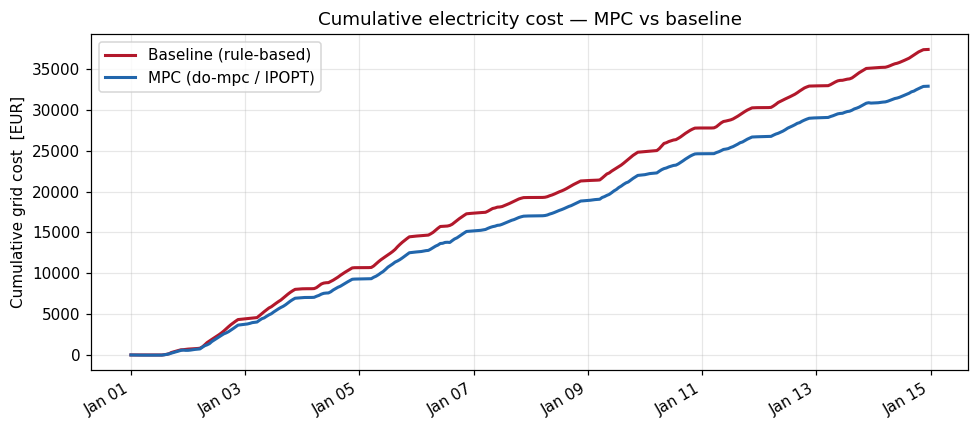

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(b.index, b.grid_cost_EUR.cumsum(), label='Baseline (rule-based)', lw=2, color='#b2182b')
ax.plot(m.index, m.grid_cost_EUR.cumsum(), label='MPC (do-mpc / IPOPT)', lw=2, color='#2166ac')
ax.set_ylabel('Cumulative grid cost  [EUR]'); ax.set_xlabel('')
ax.set_title('Cumulative electricity cost — MPC vs baseline')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig1_cumulative_cost.png', bbox_inches='tight'); plt.show()

## 3. Grid exchange vs price
Negative grid power = export. The MPC imports in cheap/negative-price hours and
exports stored energy when prices peak.

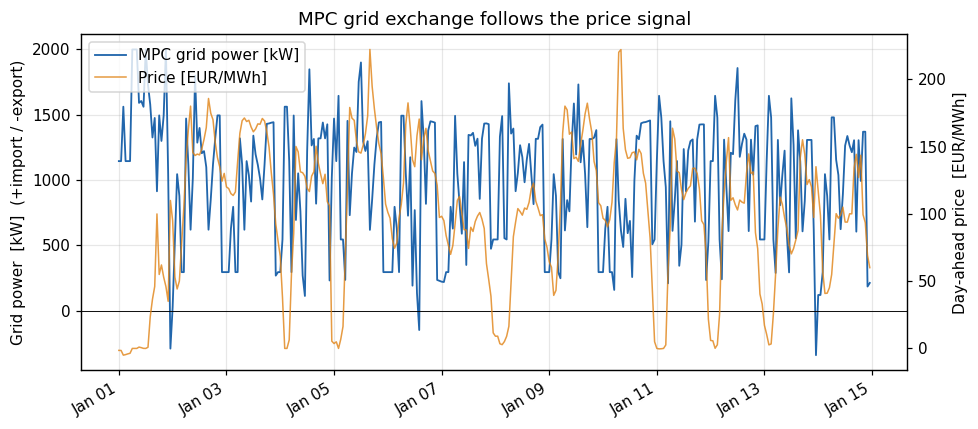

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m.u_P_grid, color='#2166ac', lw=1.2, label='MPC grid power [kW]')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Grid power  [kW]  (+import / -export)')
ax2 = ax.twinx()
ax2.plot(m.index, 1000*m.price_EUR_kWh, color='#e08214', lw=1.0, alpha=0.8, label='Price [EUR/MWh]')
ax2.set_ylabel('Day-ahead price  [EUR/MWh]'); ax2.grid(False)
ax.set_title('MPC grid exchange follows the price signal')
lines = ax.get_lines()[:1] + ax2.get_lines()[:1]
ax.legend(lines, [l.get_label() for l in lines], loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig2_grid_vs_price.png', bbox_inches='tight'); plt.show()

## 4. State-of-charge trajectories
Battery handles daily arbitrage; the hydrogen tank acts as a multi-day buffer;
the thermal store shifts heating to cheap hours.

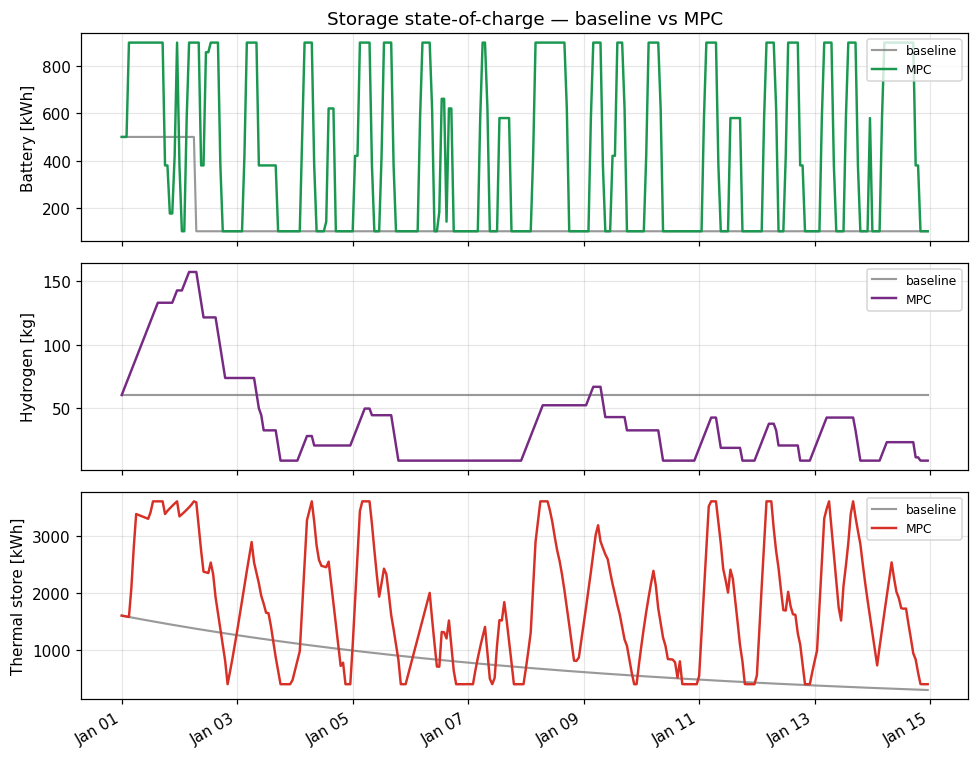

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, col, lab, col_c in zip(
        axs, ['SOC_bat_kWh', 'SOC_h2_kg', 'SOC_tes_kWh'],
        ['Battery [kWh]', 'Hydrogen [kg]', 'Thermal store [kWh]'],
        ['#1a9850', '#762a83', '#d73027']):
    ax.plot(b.index, b[col], label='baseline', lw=1.4, color='grey', alpha=0.8)
    ax.plot(m.index, m[col], label='MPC', lw=1.6, color=col_c)
    ax.set_ylabel(lab); ax.legend(loc='upper right', fontsize=8)
axs[0].set_title('Storage state-of-charge — baseline vs MPC')
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig3_soc_trajectories.png', bbox_inches='tight'); plt.show()

## 5. Greenhouse temperature
Both controllers keep the crop inside the comfort band [16, 24] °C. The MPC exploits
the band as flexibility — drifting toward the lower bound when electricity is expensive.

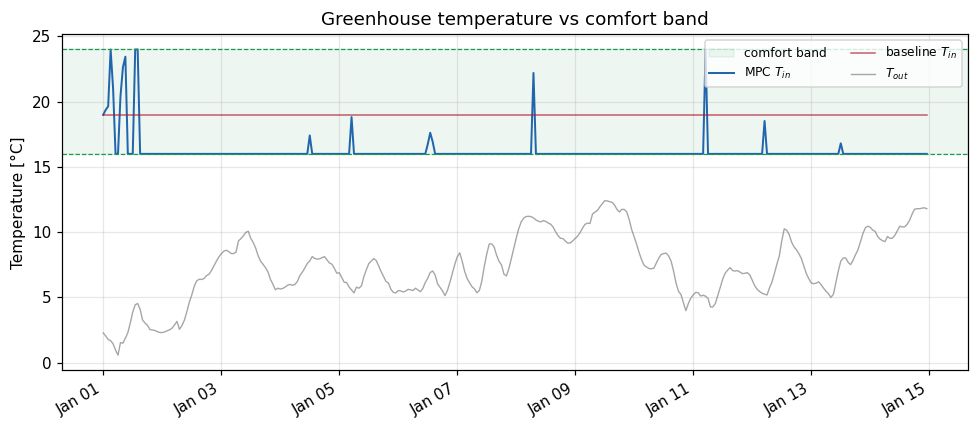

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhspan(16, 24, color='#1a9850', alpha=0.08, label='comfort band')
ax.plot(m.index, m.T_in_C, color='#2166ac', lw=1.3, label='MPC $T_{in}$')
ax.plot(b.index, b.T_in_C, color='#b2182b', lw=1.0, alpha=0.7, label='baseline $T_{in}$')
ax.plot(m.index, m.T_out_C, color='grey', lw=0.9, alpha=0.7, label='$T_{out}$')
ax.axhline(16, color='#1a9850', lw=0.8, ls='--'); ax.axhline(24, color='#1a9850', lw=0.8, ls='--')
ax.set_ylabel('Temperature [°C]'); ax.set_title('Greenhouse temperature vs comfort band')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig4_temperature.png', bbox_inches='tight'); plt.show()

## 6. Flexible heat: e-boiler load-shifting
The electric boiler (power-to-heat) is the CHP-replacement flexibility asset: the MPC
runs it in cheap hours and stores the heat, displacing expensive-hour heating.

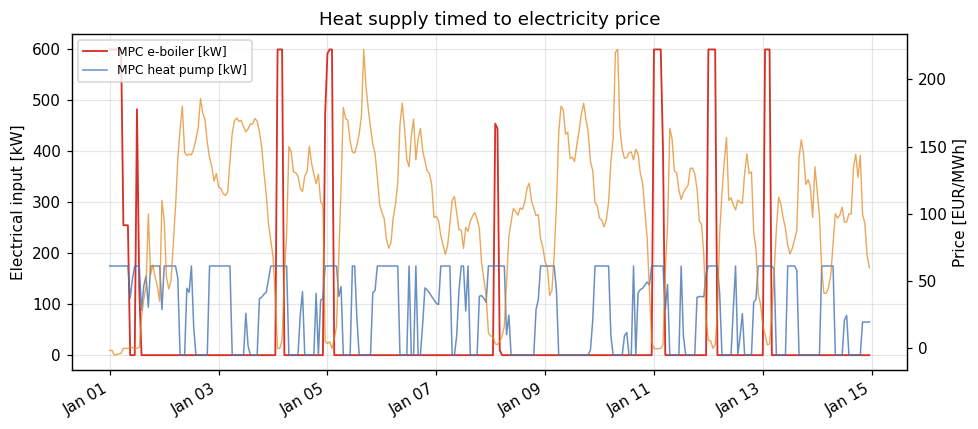

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m.index, m.u_P_eboiler, color='#d73027', lw=1.2, label='MPC e-boiler [kW]')
ax.plot(m.index, m.u_P_hp, color='#4575b4', lw=1.0, alpha=0.8, label='MPC heat pump [kW]')
ax.set_ylabel('Electrical input [kW]')
ax2 = ax.twinx(); ax2.plot(m.index, 1000*m.price_EUR_kWh, color='#e08214', lw=0.9, alpha=0.7, label='price')
ax2.set_ylabel('Price [EUR/MWh]'); ax2.grid(False)
ax.set_title('Heat supply timed to electricity price')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d')); fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIGDIR / 'fig5_heat_shifting.png', bbox_inches='tight'); plt.show()

## Takeaways

- The MPC respects the electricity balance exactly and never charges/discharges a
  store simultaneously — the formulation is physically clean.
- It beats the naive baseline by exploiting **storage arbitrage** (battery, H₂ buffer),
  **power-to-heat load-shifting** (e-boiler + thermal store), and the **thermal comfort
  band** as demand-side flexibility.
- This is the economic-dispatch layer the SPROUT project needs to replace the grid
  flexibility lost when Dutch greenhouse CHP units are phased out.